# GRU-LightGCN v3

**Changes from v2:**
- Early stopping threshold raised: patience//5 → patience//3, and only checks
  after epoch 50 (gives the cosine schedule time to warm up before judging)
- Checkpoint saves `best` model separately so RL notebook always loads the
  best HR@10 weights, not just the last epoch
- `item_popularity`, `val_data`, `test_data`, splits all saved as before


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Imports & Config

In [ ]:
import os, math, random
from collections import OrderedDict
import numpy as np
import pandas as pd
import polars as pl
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from torch.nn.functional import cosine_similarity
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = '/content/drive/MyDrive'
    print('Drive mounted.')
except Exception:
    DRIVE_ROOT = '.'

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED); random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED); torch.cuda.manual_seed_all(RANDOM_SEED)

INTERACTIONS_PATH  = os.path.join(DRIVE_ROOT, 'data2.csv')
ITEM_FEATURES_PATH = os.path.join(DRIVE_ROOT, 'item_features2.csv')
USER_FEATURES_PATH = os.path.join(DRIVE_ROOT, 'user_features2.csv')
MODEL_SAVE_PATH    = './gru_lightgcn_v3.pth'
BEST_SAVE_PATH     = './gru_lightgcn_v3_best.pth'

vocab_config = {'padding_index': 0}

train_config = {
    'batch_size': 256, 'num_epochs': 200, 'additional_epochs': 40,
    'lr': 1e-3, 'lr_resume': 1e-4, 'optimizer_betas': (0.9, 0.999),
    'weight_decay': 0.01, 'grad_clip': 1.0,
    'patience': 20,           # 20 bad 5-epoch windows = 100 epochs grace
    'early_stop_start': 50,   # don't check early stopping before epoch 50
}
model_config = {
    'hidden_dims': 128, 'num_gru_layers': 2, 'num_gnn_layers': 2,
    'max_seq_len': 50, 'vocab_size': 0, 'num_users': 0, 'num_items': 0,
    'user_feature_dim': 0, 'hidden_dropout_prob': 0.1,
    'initializer_range': 0.02, 'eps': 1e-12,
}
notebook_config = {
    'model_train_flg': True, 'model_train_resume_flg': False,
    'model_save_path': MODEL_SAVE_PATH, 'model_load_path': MODEL_SAVE_PATH,
}
print('Config ready.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.
Config ready.


## 2. Data Loading

In [ ]:
item_features_pd = pd.read_csv(ITEM_FEATURES_PATH).sort_values('item_idx').reset_index(drop=True)
item_lookup_df   = item_features_pd[['item_idx','item_id']].set_index('item_idx')
num_items = len(item_features_pd)
model_config['vocab_size'] = num_items + 1
model_config['num_items']  = num_items
print(f'Items: {num_items:,}  |  vocab_size: {model_config["vocab_size"]}')

def build_item_feature_matrix(df):
    ignore = {'item_idx','item_id','title','genres_raw','release_date_raw'}
    num_cols = [c for c in df.columns if c not in ignore|{'original_language'}
                and pd.api.types.is_numeric_dtype(df[c])]
    lang = pd.get_dummies(df['original_language'].fillna('unknown').astype(str), prefix='lang') \
           if 'original_language' in df.columns else pd.DataFrame(index=df.index)
    feat = pd.concat([df[num_cols].fillna(0), lang], axis=1).fillna(0)
    scale = [c for c in feat.columns if feat[c].nunique()>2]
    if scale: feat[scale] = StandardScaler().fit_transform(feat[scale])
    arr = feat.to_numpy(dtype=np.float32)
    pad = np.zeros((len(df)+1, arr.shape[1]), dtype=np.float32); pad[1:] = arr
    return torch.tensor(pad, dtype=torch.float32)

item_feature_tensor = build_item_feature_matrix(item_features_pd)
print(f'Item features: {item_feature_tensor.shape}')

def build_user_feature_matrix(df, thresh=0.95):
    drop = {'user_idx','user_id','first_seen','last_seen'}
    ordinal = {'user_engagement_tier','user_preferred_hour_bucket'}
    num = df.drop(columns=[c for c in drop if c in df.columns], errors='ignore').select_dtypes('number')
    keep = [c for c in num.columns if (num[c]==0).mean()<thresh and c not in ordinal]
    parts = []
    if keep:
        sub = num[keep].fillna(0).copy()
        cont = [c for c in keep if sub[c].nunique()>2]
        if cont: sub[cont] = StandardScaler().fit_transform(sub[cont])
        parts.append(sub)
    for col in ordinal:
        if col in df.columns: parts.append(pd.get_dummies(df[col].fillna(0).astype(int), prefix=col))
    feat = pd.concat(parts, axis=1).fillna(0)
    return torch.tensor(feat.to_numpy(dtype=np.float32), dtype=torch.float32)

user_features_pd    = pd.read_csv(USER_FEATURES_PATH).sort_values('user_idx').reset_index(drop=True)
user_feature_tensor = build_user_feature_matrix(user_features_pd)
model_config['user_feature_dim'] = user_feature_tensor.shape[1]
model_config['num_users']        = len(user_features_pd)
print(f'User features: {user_feature_tensor.shape}')

df = pl.read_csv(INTERACTIONS_PATH)
df = df.with_columns([
    pl.col('datetime').str.to_datetime(format='%Y-%m-%d %H:%M:%S', strict=False),
    (pl.col('item_idx')+1).alias('item_token'),
])
assert int(df['item_token'].max()) < model_config['vocab_size']
user_rows = (df.group_by(['user_id','user_idx'])
               .agg(pl.col('item_token').sort_by(pl.col('datetime')).alias('sequence'))
               .sort('user_idx'))
sequences    = user_rows['sequence'].to_list()
user_indices = user_rows['user_idx'].to_list()

train_seqs, val_data, test_data = [], [], []
train_user_idx, val_user_idx, test_user_idx = [], [], []
for seq, uidx in zip(sequences, user_indices):
    if len(seq) < 3: continue
    train_seqs.append(seq[:-2]);           train_user_idx.append(uidx)
    val_data.append((seq[:-2], seq[-2]));  val_user_idx.append(uidx)
    test_data.append((seq[:-1], seq[-1])); test_user_idx.append(uidx)
print(f'Train: {len(train_seqs):,}  Val: {len(val_data):,}  Test: {len(test_data):,}')

item_counts = df['item_token'].value_counts().to_pandas().set_index('item_token')['count']
total_int   = item_counts.sum()
pop_vec = np.zeros(model_config['vocab_size'], dtype=np.float32)
for tok, cnt in item_counts.items(): pop_vec[int(tok)] = cnt / total_int
pop_vec[0] = 1.0
item_popularity = torch.tensor(pop_vec, dtype=torch.float32)

w = np.ones(model_config['vocab_size'], dtype=np.float32)
for tok, cnt in item_counts.items(): w[int(tok)] = 1.0/(cnt**0.5)
w[0] = 0.0
item_loss_weights = torch.tensor(w, dtype=torch.float32)
print('Popularity + loss weights built.')


Items: 8,411  |  vocab_size: 8412
Item features: torch.Size([8412, 78])
User features: torch.Size([161619, 38])
Train: 72,138  Val: 72,138  Test: 72,138
Popularity + loss weights built.


## 3. Graph Construction

In [ ]:
def build_norm_adj(train_seqs, user_indices, num_users, num_items, device):
    rows_u, cols_i = [], []
    for seq, uidx in zip(train_seqs, user_indices):
        for tok in seq:
            rows_u.append(int(uidx)); cols_i.append(int(tok)-1)
    R = sp.csr_matrix((np.ones(len(rows_u), np.float32), (rows_u, cols_i)),
                       shape=(num_users, num_items))
    A = sp.vstack([sp.hstack([sp.csr_matrix((num_users,num_users)), R]),
                   sp.hstack([R.T, sp.csr_matrix((num_items,num_items))])]).tocsr()
    rs = np.array(A.sum(1)).flatten()
    d  = np.where(rs>0, 1.0/np.sqrt(rs), 0.0)
    C  = (sp.diags(d) @ A @ sp.diags(d)).tocoo()
    idx = torch.from_numpy(np.vstack([C.row,C.col]).astype(np.int64))
    val = torch.from_numpy(C.data.astype(np.float32))
    return torch.sparse_coo_tensor(idx, val, torch.Size([num_users+num_items]*2)).to(device)

device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
norm_adj = build_norm_adj(train_seqs, train_user_idx,
                           model_config['num_users'], model_config['num_items'], device)
print(f'Device: {device}  |  Adj: {list(norm_adj.shape)}  |  nnz: {norm_adj._nnz():,}')


/tmp/ipykernel_1603/1584937100.py:11: RuntimeWarning: divide by zero encountered in divide
  d  = np.where(rs>0, 1.0/np.sqrt(rs), 0.0)


Device: cuda  |  Adj: [170030, 170030]  |  nnz: 560,608


## 4. Model

In [ ]:
class UserEncoder(nn.Module):
    def __init__(self, feat_dim, H, dropout=0.1):
        super().__init__()
        self.fc1=nn.Linear(feat_dim,H); self.fc2=nn.Linear(H,H); self.gate=nn.Linear(feat_dim,H)
        self.norm=nn.LayerNorm(H); self.drop=nn.Dropout(dropout)
        for m in [self.fc1,self.fc2,self.gate]: init.xavier_uniform_(m.weight); init.zeros_(m.bias)
    def forward(self, x):
        g=torch.sigmoid(self.gate(x)); h=self.drop(F.gelu(self.fc1(x)))
        return self.norm(self.drop(self.fc2(h))*g).unsqueeze(1)

class GRULightGCN(nn.Module):
    def __init__(self, cfg, vcfg, item_feature_matrix, user_feature_dim):
        super().__init__()
        H, Nu, r = cfg['hidden_dims'], cfg['num_users'], cfg['initializer_range']
        self.item_embedding = nn.Embedding(cfg['vocab_size'], H, padding_idx=vcfg['padding_index'])
        self.user_embedding = nn.Embedding(Nu, H)
        self.item_feat_proj = nn.Linear(item_feature_matrix.shape[1], H, bias=False)
        self.fusion_gate    = nn.Parameter(torch.tensor(-2.0))
        self.gnn_gate       = nn.Parameter(torch.tensor(0.3))
        self.register_buffer('item_feat_matrix', item_feature_matrix)
        self.user_encoder = UserEncoder(user_feature_dim, H, cfg['hidden_dropout_prob'])
        self.gru = nn.GRU(H, H, num_layers=cfg['num_gru_layers'], batch_first=True,
                          dropout=cfg['hidden_dropout_prob'] if cfg['num_gru_layers']>1 else 0.0)
        self.drop     = nn.Dropout(cfg['hidden_dropout_prob'])
        self.out_norm = nn.LayerNorm(H, eps=cfg['eps'])
        self.out_proj = nn.Linear(H, cfg['vocab_size'], bias=False)
        self.out_proj.weight = self.item_embedding.weight
        self.num_gnn_layers = cfg['num_gnn_layers']
        self._init(r)

    def _init(self, r):
        init.normal_(self.item_embedding.weight, std=r)
        init.xavier_uniform_(self.user_embedding.weight)
        init.normal_(self.item_feat_proj.weight, std=r)
        for name, p in self.gru.named_parameters():
            if 'weight' in name: init.orthogonal_(p)
            elif 'bias' in name: init.zeros_(p)

    @torch.no_grad()
    def compute_gnn_item_emb(self, norm_adj):
        E0i = self.item_embedding.weight[1:].detach()
        E0u = self.user_embedding.weight.detach()
        emb = torch.cat([E0u, E0i], dim=0); layers = [emb]
        for _ in range(self.num_gnn_layers):
            emb = torch.sparse.mm(norm_adj, emb); layers.append(emb)
        final    = torch.stack(layers, dim=1).mean(dim=1)
        item_emb = final[self.user_embedding.num_embeddings:]
        pad_row  = torch.zeros(1, item_emb.shape[1], device=item_emb.device)
        return torch.cat([pad_row, item_emb], dim=0)

    def encode(self, input_ids, pad_mask, user_feats, gnn_item_emb):
        x = self.item_embedding(input_ids)
        x = x + torch.sigmoid(self.gnn_gate) * gnn_item_emb[input_ids]
        x = x + torch.sigmoid(self.fusion_gate) * self.item_feat_proj(
                self.item_feat_matrix[input_ids])
        x = x + self.user_encoder(user_feats)
        x = self.drop(x.masked_fill(pad_mask.unsqueeze(-1), 0.0))
        gru_out, h_n = self.gru(x)
        return gru_out, h_n[-1]

    def forward(self, input_ids, pad_mask, user_feats, gnn_item_emb):
        out, _ = self.encode(input_ids, pad_mask, user_feats, gnn_item_emb)
        return self.out_proj(self.out_norm(out))

    def score_next(self, input_ids, pad_mask, user_feats, gnn_item_emb):
        _, h = self.encode(input_ids, pad_mask, user_feats, gnn_item_emb)
        return self.out_proj(self.out_norm(h))

_B   = 4
_net = GRULightGCN(model_config, vocab_config, item_feature_tensor,
                   model_config['user_feature_dim']).to(device)
_gnn = _net.compute_gnn_item_emb(norm_adj)
_ids = torch.randint(1, model_config['vocab_size'], (_B, model_config['max_seq_len'])).to(device)
_out = _net(_ids, _ids.eq(0), torch.randn(_B, model_config['user_feature_dim']).to(device), _gnn)
assert _out.shape == (_B, model_config['max_seq_len'], model_config['vocab_size'])
print(f'Forward OK  |  Params: {sum(p.numel() for p in _net.parameters() if p.requires_grad):,}')
del _net, _out, _gnn


Forward OK  |  Params: 21,999,106


## 5. Dataset & Inference Helper

In [ ]:
class SeqDataset(Dataset):
    def __init__(self, sequences, user_indices, user_feature_tensor, max_len, pad_id=0):
        self.sequences=sequences; self.user_indices=user_indices
        self.uft=user_feature_tensor; self.max_len=max_len; self.pad_id=pad_id
    def __len__(self): return len(self.sequences)
    def __getitem__(self, idx):
        seq=list(self.sequences[idx]); uidx=self.user_indices[idx]
        inp,tgt = seq[:-1], seq[1:]
        inp=inp[-self.max_len:]; tgt=tgt[-self.max_len:]
        pad_n = self.max_len-len(inp)
        inp=[self.pad_id]*pad_n+inp; tgt=[-100]*pad_n+tgt
        it=torch.tensor(inp,dtype=torch.long)
        return it, torch.tensor(tgt,dtype=torch.long), it.eq(self.pad_id), self.uft[uidx]

def prepare_inference_input(history, user_feat, cfg, vcfg, device):
    L, pad = cfg['max_seq_len'], vcfg['padding_index']
    seq = list(history)[-L:]; pad_n = L-len(seq)
    padded   = [pad]*pad_n + seq
    pad_mask = [True]*pad_n + [False]*len(seq)
    return (torch.tensor(padded,  dtype=torch.long).unsqueeze(0).to(device),
            torch.tensor(pad_mask,dtype=torch.bool).unsqueeze(0).to(device),
            user_feat.unsqueeze(0).to(device))

train_loader = DataLoader(
    SeqDataset(train_seqs, train_user_idx, user_feature_tensor,
               model_config['max_seq_len'], pad_id=vocab_config['padding_index']),
    batch_size=train_config['batch_size'], shuffle=True, num_workers=2, pin_memory=True)
print(f'Train loader: {len(train_loader)} batches/epoch')


Train loader: 282 batches/epoch


## 6. Training

In [ ]:
model = GRULightGCN(model_config, vocab_config, item_feature_tensor,
                    model_config['user_feature_dim']).to(device)
item_loss_weights = item_loss_weights.to(device)
optimizer = optim.AdamW(model.parameters(), lr=train_config['lr'],
                        betas=train_config['optimizer_betas'],
                        weight_decay=train_config['weight_decay'])
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=50, T_mult=1, eta_min=1e-5)
start_epoch=0; epoch_loss_history=[]; best_val_hr=-1.0; bad_epochs=0
print(f'Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


Params: 21,999,106


Training 200 epochs.
  E1/200 | B0/282 | Loss 9.0643
  E1/200 | B100/282 | Loss 8.3456
  E1/200 | B200/282 | Loss 7.7748
Epoch 1 done. Avg loss: 8.1790
  E2/200 | B0/282 | Loss 7.4570
  E2/200 | B100/282 | Loss 7.1917
  E2/200 | B200/282 | Loss 7.3184
Epoch 2 done. Avg loss: 7.2445
  E3/200 | B0/282 | Loss 6.5240
  E3/200 | B100/282 | Loss 6.6355
  E3/200 | B200/282 | Loss 6.7938
Epoch 3 done. Avg loss: 6.6795
  E4/200 | B0/282 | Loss 6.1109
  E4/200 | B100/282 | Loss 6.4163
  E4/200 | B200/282 | Loss 6.1814
Epoch 4 done. Avg loss: 6.2608
  E5/200 | B0/282 | Loss 5.7130
  E5/200 | B100/282 | Loss 5.5275
  E5/200 | B200/282 | Loss 6.1946
Epoch 5 done. Avg loss: 5.9155
  E6/200 | B0/282 | Loss 5.4255
  E6/200 | B100/282 | Loss 5.6878
  E6/200 | B200/282 | Loss 5.9666
Epoch 6 done. Avg loss: 5.6151
  E7/200 | B0/282 | Loss 5.2293
  E7/200 | B100/282 | Loss 5.4210
  E7/200 | B200/282 | Loss 5.4045
Epoch 7 done. Avg loss: 5.3447
  E8/200 | B0/282 | Loss 5.0627
  E8/200 | B100/282 | Loss 5.5

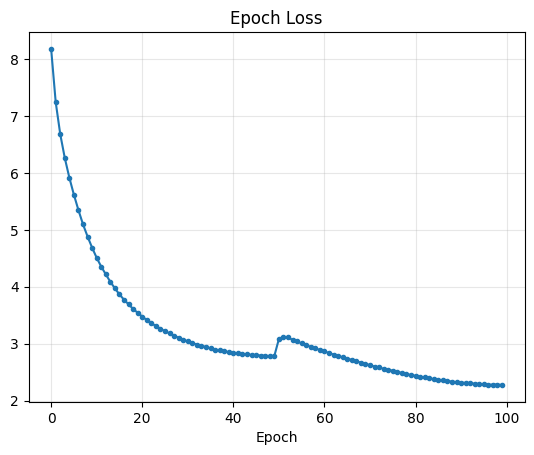

Best Val HR@10: 0.2280


In [ ]:
if notebook_config['model_train_flg']:
    if notebook_config['model_train_resume_flg'] and os.path.exists(notebook_config['model_load_path']):
        ckpt = torch.load(notebook_config['model_load_path'], map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        start_epoch = ckpt['epoch']+1
        num_epochs  = start_epoch+train_config['additional_epochs']
        for g2 in optimizer.param_groups: g2['lr']=train_config['lr_resume']
        print(f'Resuming from epoch {start_epoch}')
    else:
        num_epochs = train_config['num_epochs']
        print(f'Training {num_epochs} epochs.')

    for epoch in range(start_epoch, num_epochs):
        model.train()
        gnn_item_emb = model.compute_gnn_item_emb(norm_adj)
        epoch_loss=0.0; valid=0
        for i,(inp_b,lbl_b,pad_b,usr_b) in enumerate(train_loader):
            inp_b=inp_b.to(device); lbl_b=lbl_b.to(device)
            pad_b=pad_b.to(device); usr_b=usr_b.to(device)
            logits = model(inp_b, pad_b, usr_b, gnn_item_emb)
            loss   = F.cross_entropy(logits.reshape(-1,model_config['vocab_size']),
                                     lbl_b.reshape(-1), ignore_index=-100,
                                     weight=item_loss_weights)
            if not torch.isfinite(loss): optimizer.zero_grad(); continue
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), train_config['grad_clip'])
            optimizer.step()
            epoch_loss+=loss.item(); valid+=1
            if i%100==0:
                print(f'  E{epoch+1}/{num_epochs} | B{i}/{len(train_loader)} | Loss {loss.item():.4f}')

        scheduler.step()
        avg = epoch_loss/max(valid,1); epoch_loss_history.append(avg)
        print(f'Epoch {epoch+1} done. Avg loss: {avg:.4f}')

        # Always save latest checkpoint with full data for RL notebook
        torch.save({
            'epoch': epoch, 'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(), 'loss': avg,
            'model_config': model_config, 'vocab_config': vocab_config,
            'val_data': val_data, 'test_data': test_data,
            'val_user_idx': val_user_idx, 'test_user_idx': test_user_idx,
            'train_seqs': train_seqs, 'train_user_idx': train_user_idx,
            'item_popularity': item_popularity,
        }, notebook_config['model_save_path'])

        # Early stopping — only after epoch 50, patience = 20 windows of 5
        if (epoch+1) % 5 == 0 and (epoch+1) >= train_config['early_stop_start']:
            model.eval()
            gnn_val = model.compute_gnn_item_emb(norm_adj)
            hits=[]
            with torch.no_grad():
                for (hist,tgt),uidx in zip(val_data[:500],val_user_idx[:500]):
                    ids_t,mask_t,uf_t = prepare_inference_input(
                        hist, user_feature_tensor[uidx], model_config, vocab_config, device)
                    sc = model.score_next(ids_t, mask_t, uf_t, gnn_val)[0]
                    sc[vocab_config['padding_index']]=-1e9
                    for item in hist: sc[item]=-1e9
                    hits.append(1.0 if int(tgt) in torch.argsort(sc,descending=True).tolist()[:10] else 0.0)
            hr=float(np.mean(hits))
            print(f'  Quick Val HR@10: {hr:.4f}')
            model.train()
            if hr > best_val_hr:
                best_val_hr = hr; bad_epochs = 0
                # Save best separately — this is what the RL notebook loads
                torch.save({
                    'epoch': epoch, 'model_state_dict': model.state_dict(),
                    'loss': avg, 'model_config': model_config,
                    'vocab_config': vocab_config,
                    'val_data': val_data, 'test_data': test_data,
                    'val_user_idx': val_user_idx, 'test_user_idx': test_user_idx,
                    'train_seqs': train_seqs, 'train_user_idx': train_user_idx,
                    'item_popularity': item_popularity,
                }, BEST_SAVE_PATH)
                print(f'  >>> Best HR@10={hr:.4f} saved to {BEST_SAVE_PATH}')
            else:
                bad_epochs += 1
                # patience//3 gives 7 windows = 35 epochs of grace
                if bad_epochs >= train_config['patience']//3:
                    print(f'Early stopping at epoch {epoch+1}.')
                    break

    plt.plot(epoch_loss_history, marker='o', markersize=3)
    plt.title('Epoch Loss'); plt.xlabel('Epoch'); plt.grid(True, alpha=0.3)
    plt.savefig('gru_lightgcn_v3_loss.png', dpi=120); plt.show()
    print(f'Best Val HR@10: {best_val_hr:.4f}')
else:
    ckpt = torch.load(BEST_SAVE_PATH, map_location=device)
    model.load_state_dict(ckpt['model_state_dict']); model.eval(); print('Best model loaded.')


## 7. Evaluation

In [ ]:
def evaluate_all(model, norm_adj, eval_data, user_indices, user_feature_tensor,
                 cfg, vcfg, device, k_list=(5,10,20)):
    model.eval()
    gnn = model.compute_gnn_item_emb(norm_adj)
    hits={k:[] for k in k_list}; ndcgs={k:[] for k in k_list}; rr=[]
    with torch.no_grad():
        for (history,target),uidx in zip(eval_data,user_indices):
            ids_t,mask_t,uf_t = prepare_inference_input(
                history, user_feature_tensor[int(uidx)], cfg, vcfg, device)
            sc = model.score_next(ids_t,mask_t,uf_t,gnn)[0].clone()
            sc[vcfg['padding_index']]=-1e9
            for item in history: sc[item]=-1e9
            ranked = torch.argsort(sc,descending=True).tolist()
            rr.append(1.0/(ranked.index(int(target))+1) if int(target) in ranked else 0.0)
            for k in k_list:
                if int(target) in ranked[:k]:
                    hits[k].append(1.0); ndcgs[k].append(1.0/math.log2(ranked.index(int(target))+2))
                else:
                    hits[k].append(0.0); ndcgs[k].append(0.0)
    res={k:{f'HR@{k}':round(float(np.mean(hits[k])),4),
            f'NDCG@{k}':round(float(np.mean(ndcgs[k])),4)} for k in k_list}
    res['MRR']={'MRR':round(float(np.mean(rr)),4)}
    return res

# Load best model for final eval
ckpt_best = torch.load(BEST_SAVE_PATH, map_location=device)
model.load_state_dict(ckpt_best['model_state_dict'])

print('=== Validation (best checkpoint) ===')
val_m = evaluate_all(model,norm_adj,val_data,val_user_idx,user_feature_tensor,model_config,vocab_config,device)
for m in val_m.values(): print(f'  {m}')
print('\n=== Test ===')
test_m = evaluate_all(model,norm_adj,test_data,test_user_idx,user_feature_tensor,model_config,vocab_config,device)
for m in test_m.values(): print(f'  {m}')
print('\nBERT4Rec v2 reference: HR@10=0.3085  NDCG@10=0.2081  MRR=0.1966')
print(f'Checkpoint for RL: {BEST_SAVE_PATH}')


=== Validation (best checkpoint) ===
  {'HR@5': 0.1688, 'NDCG@5': 0.1213}
  {'HR@10': 0.2239, 'NDCG@10': 0.139}
  {'HR@20': 0.2884, 'NDCG@20': 0.1553}
  {'MRR': 0.1223}

=== Test ===
  {'HR@5': 0.1303, 'NDCG@5': 0.091}
  {'HR@10': 0.1836, 'NDCG@10': 0.1082}
  {'HR@20': 0.2477, 'NDCG@20': 0.1243}
  {'MRR': 0.0947}

BERT4Rec v2 reference: HR@10=0.3085  NDCG@10=0.2081  MRR=0.1966
Checkpoint for RL: ./gru_lightgcn_v3_best.pth


## 8. Demo

In [ ]:
def get_item_name(tok, lookup, vcfg):
    if tok==vcfg['padding_index']: return '<PAD>'
    iidx=int(tok)-1
    return lookup.loc[iidx,'item_id'] if iidx in lookup.index else f'unk_{tok}'

hist,tgt=val_data[0]; uidx=val_user_idx[0]
gnn = model.compute_gnn_item_emb(norm_adj)
ids_t,mask_t,uf_t = prepare_inference_input(hist, user_feature_tensor[uidx], model_config, vocab_config, device)
with torch.no_grad():
    sc = model.score_next(ids_t,mask_t,uf_t,gnn)[0].clone()
sc[vocab_config['padding_index']]=-1e9
for item in hist: sc[item]=-1e9
probs=torch.softmax(sc,0)
top_v,top_i=torch.topk(probs,10)
true_name=get_item_name(tgt,item_lookup_df,vocab_config)
print(f'User: {uidx}  |  True next: {true_name}')
for i,p in zip(top_i,top_v):
    name=get_item_name(i.item(),item_lookup_df,vocab_config)
    print(f'  {name:<30}  p={p.item():.6f}{"  <- TRUE" if name==true_name else ""}')
print(f'\nGRU-LightGCN v3 complete. RL notebook loads: {BEST_SAVE_PATH}')


User: 1  |  True next: d601124c11
  13e9f8fac8                      p=0.084043
  7881874d7b                      p=0.082028
  12ca3837f3                      p=0.073323
  304170bafa                      p=0.058922
  a8df8dd2f3                      p=0.053594
  c7c124e409                      p=0.033302
  ec0ba75a26                      p=0.030611
  3cdf0f6584                      p=0.026839
  cad24feca2                      p=0.024156
  a453f044cf                      p=0.023908

GRU-LightGCN v3 complete. RL notebook loads: ./gru_lightgcn_v3_best.pth
